In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sb
import pickle
import matplotlib.pyplot as plt
import PcmPy as pcm
import EFC_learningfMRI.globals as gl
import EFC_learningfMRI.pcm as pcm_
import EFC_learningfMRI.vis as vis
import EFC_learningfMRI.util as util
from EFC_learningfMRI.G_matrix import G_sorted

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants
                       # the shade pcm.model_plot uses for the band

# Component model

Components and corresponding hypothesis about representational geometry:

- **type**     : trained vs. untrained, geometry reflects which chords are practiced
- **trained**  : trained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *trained* chords)
- **untrained**: untrained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *untrained* chords)
- **finger**   : geometry reflects which fingers are used in each chord
- **pattern**  : geometry reflects which fingers are used in each chord, and in what direction (i.e., flexion or extension)
- **flexion**  : geometry reflects how many fingers in each chord are pressed in flexion direction
- **force_raw**: geometry reflects the *signed* force the participant actually produced, so chords that use the same fingers in opposite directions are far apart
- **force_abs**: geometry reflects the *absolute* force actually produced, i.e. which fingers were pressed and how hard, with flexion and extension collapsed onto each other
- **force_der**: geometry reflects the *absolute derivative* of the force actually produced, i.e. how fast each finger changed force
- **base**     : the geometry the ROI already has, i.e. the group-mean observed G of session 3, so the components above are fitted on what that baseline leaves over

*The **finger**, **pattern** and **flexion** components are different in each participant, depending on the assigned trained and untrained chords 

*The **force_raw**, **force_abs** and **force_der** components are the average second-moment matrices of the 5-finger force in session 3, so they ask how much of the neural geometry is already accounted for by the force geometry. 

*The **base** component is the same for every participant of an ROI but different across ROIs, and the participant being fitted is one of the ones averaged into it.

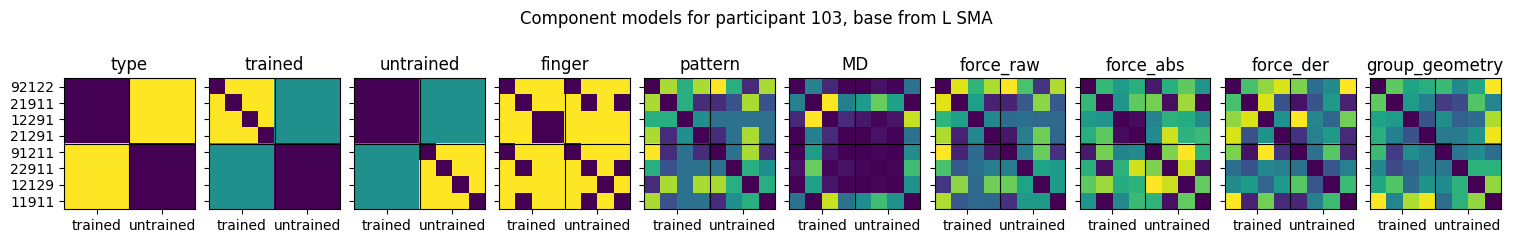

In [3]:
sn = 103
M, comp_names = pcm_.make_models(sn, glm=glm, Hem=H, roi=rois[0], force=True)   # Hem and roi bring in the ROI's base component
Mc = M[-2]

trained_untrained = pcm_.get_trained_and_untrained(sn)

fig, axs = plt.subplots(1, Mc.Gc.shape[0], sharex=True, sharey=True, figsize=(15, 2.5), constrained_layout=True)

for i, G in enumerate(Mc.Gc):
    ax = axs[i]
    d = pcm.G_to_dist(G)
    ax.imshow(d)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(trained_untrained)
    ax.set_title(comp_names[i])

fig.suptitle(f'Component models for participant {sn}, base from {H} {rois[0]}')

fig.savefig('figures/components.pdf')

plt.show()

## Neural dissimilarities in session 3

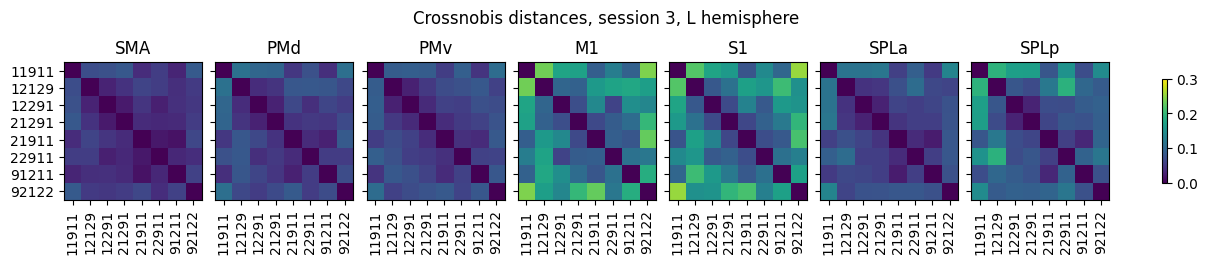

In [4]:
session = 3

D = np.zeros((len(sns), len(rois), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    for r, roi in enumerate(rois):
        fname = f'G_obs_raw.within_session.{session}.glm{glm}.{H}.{roi}.npy'
        G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
        G     = G_sorted(G, sn, order=gl.chordID)     # stored trained-first, put on a common chord order
        D[s, r] = pcm.G_to_dist(G)                    # crossnobis distances

fig, axs = plt.subplots(1, len(rois), figsize=(12, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, .3

for r, roi in enumerate(rois):
    ax = axs[r]
    im = ax.imshow(D[:, r].mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

fig.colorbar(im, ax=axs, fraction=.005)

fig.suptitle(f'Crossnobis distances, session {session}, {H} hemisphere')

plt.show()

## Force dissimilarities in session 3

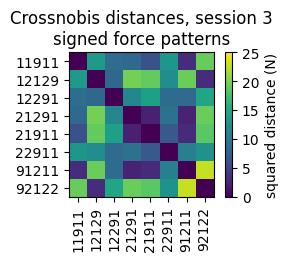

In [5]:
D = np.zeros((len(sns), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    fname = f'G_obs_raw.within_session.{session}.force.raw.npy'
    G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
    G     = G_sorted(G, sn, order=gl.chordID)   # stored trained-first, put on a common chord order
    D[s]  = pcm.G_to_dist(G)                    # crossnobis distances

fig, ax = plt.subplots(figsize=(3, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, 25

im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
ax.set_xticks(np.arange(8))
ax.set_xticklabels(gl.chordID, rotation=90)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(gl.chordID)

fig.colorbar(im, ax=ax, fraction=.05, label='squared distance (N)')

ax.set_title(f'Crossnobis distances, session {session}\nsigned force patterns')

plt.show()

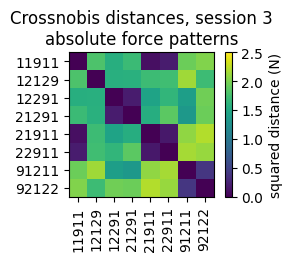

In [6]:
D = np.zeros((len(sns), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    fname = f'G_obs_raw.within_session.{session}.force.abs.npy'
    G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
    G     = G_sorted(G, sn, order=gl.chordID)     # stored trained-first, put on a common chord order
    D[s] = pcm.G_to_dist(G)                    # crossnobis distances

fig, ax = plt.subplots(figsize=(3, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, 2.5

im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
ax.set_xticks(np.arange(8))
ax.set_xticklabels(gl.chordID, rotation=90)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(gl.chordID)

fig.colorbar(im, ax=ax, fraction=.05, label='squared distance (N)')

ax.set_title(f'Crossnobis distances, session {session}\nabsolute force patterns')

plt.show()

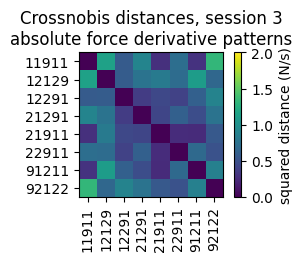

In [7]:
D = np.zeros((len(sns), len(gl.chordID), len(gl.chordID)))

for s, sn in enumerate(sns):
    fname = f'G_obs_raw.within_session.{session}.force.der.npy'
    G     = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', fname))
    G     = G_sorted(G, sn, order=gl.chordID)     # stored trained-first, put on a common chord order
    D[s] = pcm.G_to_dist(G)                    # crossnobis distances

fig, ax = plt.subplots(figsize=(3, 2.5), constrained_layout=True, sharex=True, sharey=True)

vmin, vmax = 0, 2

im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax, cmap='viridis')
ax.set_xticks(np.arange(8))
ax.set_xticklabels(gl.chordID, rotation=90)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(gl.chordID)

fig.colorbar(im, ax=ax, fraction=.05, label='squared distance (N/s)')

ax.set_title(f'Crossnobis distances, session {session}\nabsolute force derivative patterns')

plt.show()

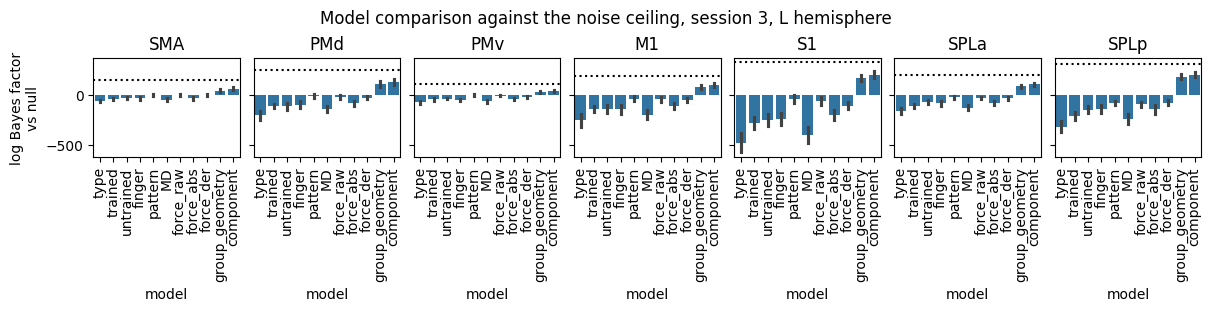

In [26]:
session = 3

LL = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'likelihood.{atlas}.glm{glm}.tsv'), sep='\t')
LL = LL.rename_axis(columns='model')              # model_plot melts on the columns name, which read_csv drops
LL = LL[LL.Hem == H]

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(12, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    plt.sca(ax)                                   # model_plot draws on the current axes

    ll = LL[(LL.roi == roi) & (LL.session == session)].drop(columns=['sn', 'session', 'Hem', 'roi'])
    pcm.model_plot(ll, null_model='null', noise_ceiling='ceil', errorbar='se', noise_ceil_col='k')

    ax.tick_params(axis='x', labelrotation=90)    # set_xticks would drop the model names
    ax.set_ylabel('log Bayes factor\nvs null' if r == 0 else None)
    ax.set_title(roi)

fig.suptitle(f'Model comparison against the noise ceiling, session {session}, {H} hemisphere')

plt.show()

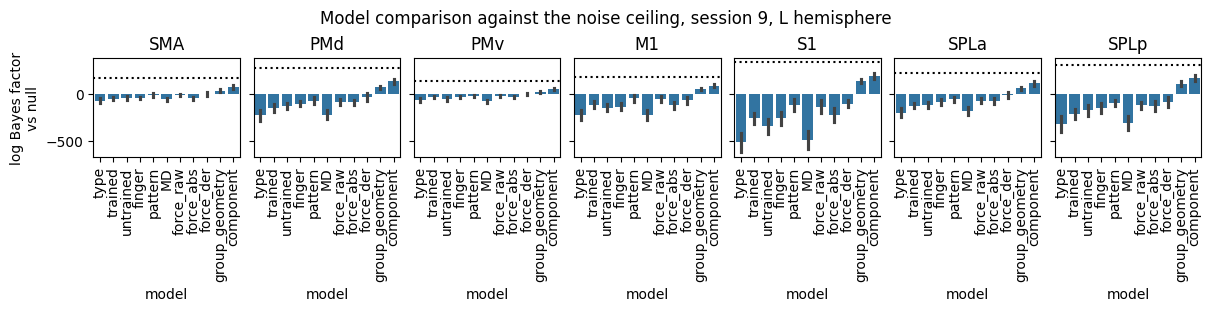

In [27]:
session = 9

LL = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'likelihood.{atlas}.glm{glm}.tsv'), sep='\t')
LL = LL.rename_axis(columns='model')              # model_plot melts on the columns name, which read_csv drops
LL = LL[LL.Hem == H]

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(12, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    plt.sca(ax)                                   # model_plot draws on the current axes

    ll = LL[(LL.roi == roi) & (LL.session == session)].drop(columns=['sn', 'session', 'Hem', 'roi'])
    pcm.model_plot(ll, null_model='null', noise_ceiling='ceil', errorbar='se', noise_ceil_col='k')

    ax.tick_params(axis='x', labelrotation=90)    # set_xticks would drop the model names
    ax.set_ylabel('log Bayes factor\nvs null' if r == 0 else None)
    ax.set_title(roi)

fig.suptitle(f'Model comparison against the noise ceiling, session {session}, {H} hemisphere')

plt.show()

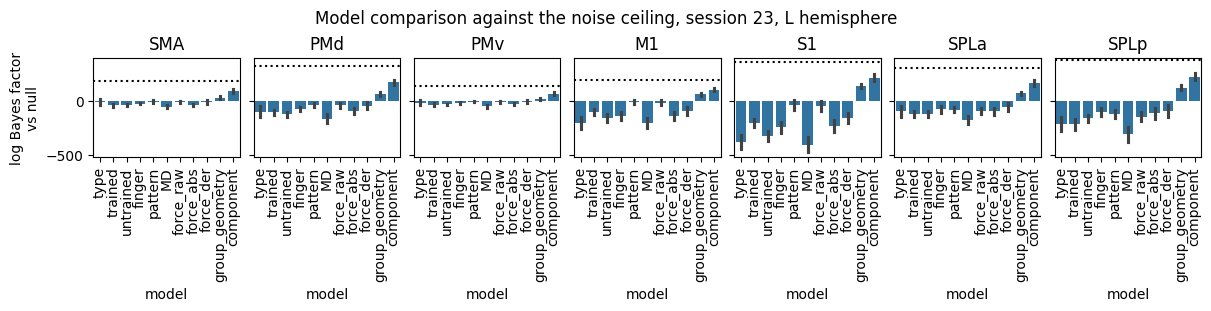

In [28]:
session = 23

LL = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'likelihood.{atlas}.glm{glm}.tsv'), sep='\t')
LL = LL.rename_axis(columns='model')              # model_plot melts on the columns name, which read_csv drops
LL = LL[LL.Hem == H]

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(12, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    plt.sca(ax)                                   # model_plot draws on the current axes

    ll = LL[(LL.roi == roi) & (LL.session == session)].drop(columns=['sn', 'session', 'Hem', 'roi'])
    pcm.model_plot(ll, null_model='null', noise_ceiling='ceil', errorbar='se', noise_ceil_col='k')

    ax.tick_params(axis='x', labelrotation=90)    # set_xticks would drop the model names
    ax.set_ylabel('log Bayes factor\nvs null' if r == 0 else None)
    ax.set_title(roi)

fig.suptitle(f'Model comparison against the noise ceiling, session {session}, {H} hemisphere')

plt.show()

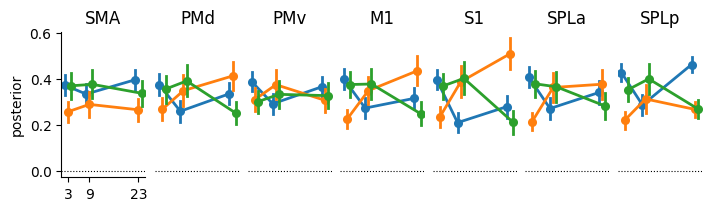

In [49]:
mf_likelihood = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'model_family.likelihood.{atlas}.glm{glm}.tsv'), sep='\t')

cols = [
        #'finger+pattern+MD+group_geometry', 
        'finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
        'trained+finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
        'untrained+finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
        #'type+finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
        ]                      # any columns of mf_likelihood

k    = np.array([0 if c == 'null' else len(c.split('+')) for c in cols])  # components per model
crit = mf_likelihood[cols].to_numpy() - k                             # AIC, as model_posterior does
crit = crit - crit.max(axis=1, keepdims=True)                         # numerical stability
post = np.exp(crit) / np.exp(crit).sum(axis=1, keepdims=True)

posterior = pd.DataFrame(post, columns=cols, index=mf_likelihood.index)
posterior[['sn', 'session', 'Hem', 'roi']] = mf_likelihood[['sn', 'session', 'Hem', 'roi']]

posterior = pd.melt(posterior, id_vars=['sn', 'session', 'Hem', 'roi'], value_vars=cols, var_name='model', value_name='posterior')

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, posterior, rois, y='posterior', x='session', hue='model',  kind='point', estimator='mean', dodge=.3, add_zero=True, legend=False)

In [38]:
mf_likelihood.columns

Index(['null', 'type', 'trained', 'untrained', 'finger', 'pattern', 'MD',
       'force_raw', 'force_abs', 'force_der',
       ...
       'type+trained+untrained+finger+MD+force_raw+force_abs+force_der+group_geometry',
       'type+trained+untrained+pattern+MD+force_raw+force_abs+force_der+group_geometry',
       'type+trained+finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
       'type+untrained+finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
       'trained+untrained+finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
       'type+trained+untrained+finger+pattern+MD+force_raw+force_abs+force_der+group_geometry',
       'sn', 'session', 'Hem', 'roi'],
      dtype='object', length=1028)

In [20]:
tr_untr

,weight,component,log_bf,sn,Hem,roi,session
1,9.060124e-04,trained,-0.622373,101,L,SMA,3
2,2.455379e-11,untrained,-1.070416,101,L,SMA,3
11,2.051162e-09,trained,-0.998313,101,L,PMd,3
12,1.647245e-09,untrained,-0.999671,101,L,PMd,3
21,2.466514e-03,trained,-0.392713,101,L,PMv,3
...,...,...,...,...,...,...,...
6622,6.666691e-09,untrained,-1.000008,118,L,S1,23
6631,1.212549e-09,trained,-0.948901,118,L,SPLa,23
6632,6.817098e-10,untrained,-0.985280,118,L,SPLa,23
6641,7.299765e-04,trained,-1.000076,118,L,SPLp,23


           T  dof     p_val          CI95   roi  session
0   0.293211   15  0.386689  [-1.71, inf]   SMA        3
1   0.899760   15  0.191233  [-0.82, inf]   SMA        9
2  -0.553730   15  0.706038  [-1.33, inf]   SMA       23
3   0.524126   15  0.303925  [-0.66, inf]   PMd        3
4  -0.079709   15  0.531239   [-0.8, inf]   PMd        9
5   0.988370   15  0.169324  [-0.64, inf]   PMd       23
6   0.972733   15  0.173056  [-0.97, inf]   PMv        3
7  -1.020483   15  0.838161  [-0.84, inf]   PMv        9
8  -1.249493   15  0.884685  [-1.07, inf]   PMv       23
9  -0.441731   15  0.667507  [-1.16, inf]    M1        3
10  0.456691   15  0.327218  [-0.99, inf]    M1        9
11  2.052436   15  0.029002   [0.22, inf]    M1       23
12  0.242484   15  0.405845  [-1.02, inf]    S1        3
13  1.710075   15  0.053925  [-0.06, inf]    S1        9
14  2.152642   15  0.024017   [0.55, inf]    S1       23
15  0.128437   15  0.449755  [-1.58, inf]  SPLa        3
16  0.672208   15  0.255837  [-

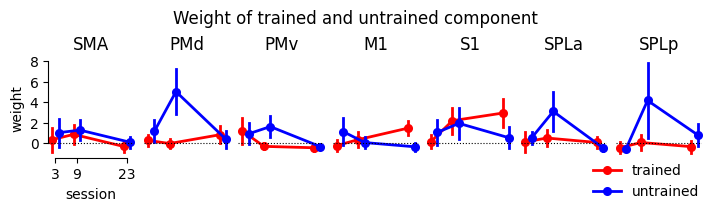

In [21]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, tr_untr, rois, y='log_bf', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3, add_zero=True)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of trained and untrained component')

ttest = util.ttest_im_sess(tr_untr[tr_untr.component=='trained'], rois, y='log_bf', x='session', alternative='greater')

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/component_model_trained_untrained.pdf')

plt.show()

           T  dof     p_val          CI95   roi  session
0  -0.785213   15  0.777723  [-0.01, inf]   SMA        3
1  -0.828861   15  0.789911  [-0.03, inf]   SMA        9
2  -0.111915   15  0.543812  [-0.01, inf]   SMA       23
3  -0.232650   15  0.590411  [-0.01, inf]   PMd        3
4  -1.873703   15  0.959707  [-0.05, inf]   PMd        9
5   0.413604   15  0.342508  [-0.01, inf]   PMd       23
6   0.644974   15  0.264343  [-0.02, inf]   PMv        3
7  -1.803911   15  0.954319  [-0.05, inf]   PMv        9
8  -0.932879   15  0.817172  [-0.02, inf]   PMv       23
9  -0.774897   15  0.774778  [-0.03, inf]    M1        3
10 -0.243539   15  0.594556  [-0.02, inf]    M1        9
11  1.942200   15  0.035566    [0.0, inf]    M1       23
12 -0.510945   15  0.691587  [-0.02, inf]    S1        3
13  0.207837   15  0.419076  [-0.02, inf]    S1        9
14  2.466120   15  0.013099   [0.01, inf]    S1       23
15 -0.813951   15  0.785797  [-0.02, inf]  SPLa        3
16 -1.204255   15  0.876425  [-

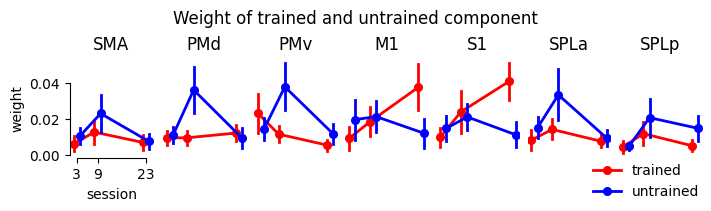

In [23]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, tr_untr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of trained and untrained component')

ttest = util.ttest_im_sess(tr_untr, rois, y='weight', x='session', hue='component', hue_order=hue_order, alternative='greater')

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/component_model_trained_untrained.pdf')

plt.show()

/tmp/ipykernel_2187373/1785719960.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(frameon=False, loc='lower right')


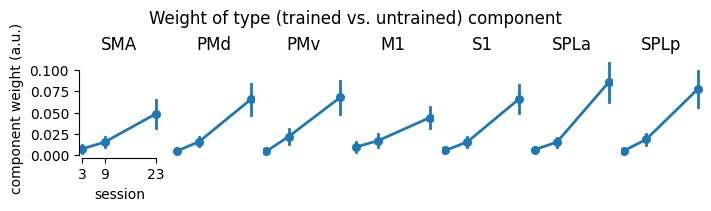

In [6]:
comp_model_repr = comp_model[comp_model.component=='type']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, comp_model_repr, rois, y='weight', x='session', kind='point', dodge=.3, estimator='mean')

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('component weight (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of type (trained vs. untrained) component')

fig.savefig('figures/component_model_pattern_flexion.pdf')

plt.show()

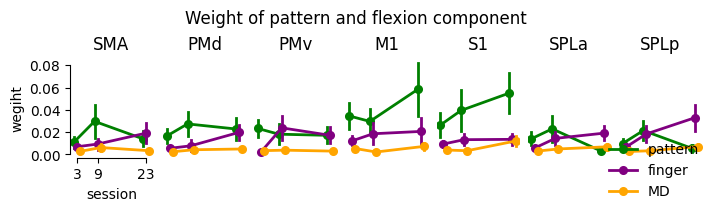

In [24]:
hue_order, palette = ['pattern', 'finger', 'MD'], ['green', 'purple', 'orange']
comp_model_repr = comp_model[comp_model.component.isin(hue_order)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, comp_model_repr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', dodge=.3, estimator='mean')
#plot_im_sess(fig, axs, comp_model_repr, rois, y='weight_norm', x='session', hue='component', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('wegiht')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of pattern and flexion component')

fig.savefig('figures/component_model_pattern_flexion.pdf')

plt.show()

/tmp/ipykernel_2187373/1646341228.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(frameon=False, loc='lower right')


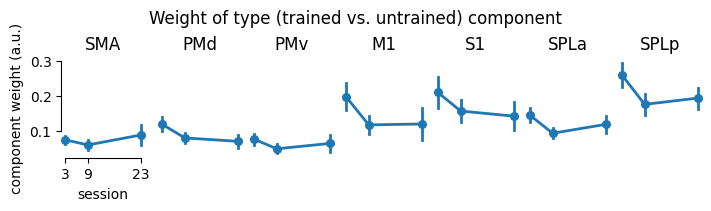

In [8]:
comp_model_repr = comp_model[comp_model.component=='group_geometry']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

vis.plot_im_sess(fig, axs, comp_model_repr, rois, y='weight', x='session', kind='point', dodge=.3, estimator='mean')

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('component weight (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of type (trained vs. untrained) component')

fig.savefig('figures/component_model_pattern_flexion.pdf')

plt.show()